# Intro Graph Neural Network (GNNs)

In [1]:
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
H = nx.DiGraph()

In [3]:
H.add_nodes_from([
  (0, {"color": "blue", "size": 250}),

  (1, {"color": "yellow", "size": 400}),

  (2, {"color": "orange", "size": 150}),

  (3, {"color": "red", "size": 600})


])

H.add_edges_from([
  (0, 1),

  (1, 2),

  (1, 0),

  (1, 3),

  (2, 3),

  (3,0)


])

In [4]:
node_colors = nx.get_node_attributes(H, "color").values()
colors = list(node_colors)
node_sizes = nx.get_node_attributes(H, "size").values()
sizes = list(node_sizes)

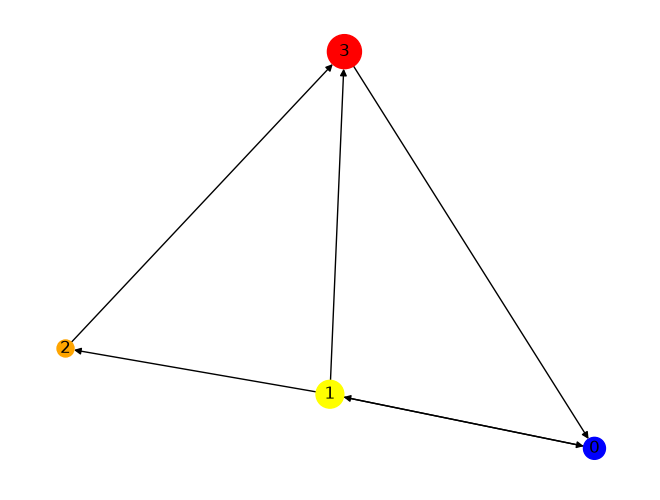

In [5]:
nx.draw(H, with_labels=True, node_color=colors, node_size=sizes)

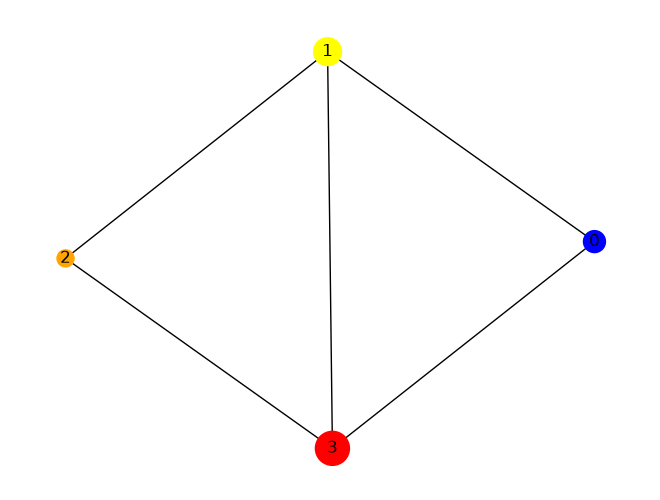

In [6]:
G = H.to_undirected()
nx.draw(G, with_labels=True, node_color=colors, node_size=sizes)

# PyGeometric

In [7]:
# !pip install torch # install sekali aja habis itu komen lagi

In [8]:
%%capture
import os
import torch
import warnings
# os.environ['TORCH'] = torch.__version__ # run kalo diperluin aja
# os.environ['PYTHONWARNINGS'] = "ignore" # ignore semua warning :D
warnings.filterwarnings("ignore")

# !pip install torch-scatter -f https://data.pyg.org/whl/torch-${TORCH}.html
# !pip install torch-sparse -f https://data.pyg.org/whl/torch-${TORCH}.html
# !pip install git+https://github.com/pyg-team/pytorch_geometric.git

In [9]:
from torch_geometric.datasets import Planetoid
from torch_geometric.transforms import NormalizeFeatures

In [10]:
dataset = Planetoid(root='data/Planetoid', name='Cora', transform=NormalizeFeatures())

print(f'Dataset: {dataset}:')
print('======================')
print(f'Number of graphs: {len(dataset)}')
print(f'Number of features: {dataset.num_features}')
print(f'Number of classes: {dataset.num_classes}')

data = dataset[0]
print(data)

Dataset: Cora():
Number of graphs: 1
Number of features: 1433
Number of classes: 7
Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])


In [11]:
print(dataset[0])

Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])


> Cora Data ini ternyata berisi 2708 nodes, 10566 edges, 1433 features, dan 7 class

### Klasifikasi Node dengan GNN

Jadi disini dibuat struktur model GCN (Graph Convolutional Network) yang berisi 2 GCNConv layer dengan aktivasi relu dan juga dropout rate 0.5, dengan modelnya berisi 16 channel
**GCN Layer:**
$$
x_v^{(l+1)} = W^{(l+1)} \sum_{w \in N(v) \cup \{v\}} \frac{1}{c_{w,v}} \, x_w^{(l)}
$$

| Simbol | Arti |
|:---|:---|
| $v$ | Node target yang sedang diperbarui representasinya. |
| $w$ | Node tetangga dari $v$ yang ikut diagregasi. |
| $N(v)$ | Himpunan tetangga langsung dari $v$ (tanpa self-loop). |
| $\\{v\\}$ | Node $v$ itu sendiri. |
| $N(v) \cup \\{v\\}$ | Tetangga $v$ **plus** $v$ sendiri → disebut **self-loop**. |
| $l$ | Indeks layer. $l=0$ berarti fitur input awal. |
| $x_v^{(l)}$ | Vektor fitur / hidden state node $v$ pada layer $l$. |
| $x_v^{(l+1)}$ | Vektor fitur baru node $v$ setelah agregasi dan transformasi. |
| $x_w^{(l)}$ | Vektor fitur node tetangga $w$ pada layer $l$. |
| $W^{(l+1)}$ | Matriks bobot **learnable** untuk layer ke-$(l+1)$. Ukuran $d_{\text{out}} \times d_{\text{in}}$. |
| $c_{w,v}$ | Koefisien normalisasi untuk pasangan $(w,v)$. Biasanya $c_{w,v} = \sqrt{\deg(w)\deg(v)}$. |
| $1/c_{w,v}$ | Faktor normalisasi agar node berderajat tinggi tidak mendominasi. |
| $\sum$ | Operasi agregasi (penjumlahan) yang **permutation-invariant**. |
| $\sigma(\cdot)$ | Fungsi aktivasi non-linear (ReLU, dll). Belum tertulis di rumus. |


### Apa yang Sebenarnya Terjadi?

Langkah demi langkah:

1. **Kumpulkan pesan** dari semua tetangga $w \in N(v)$ dan dari $v$ sendiri.
2. **Normalisasi** tiap pesan dengan $1/c_{w,v}$.
3. **Jumlahkan** semua pesan yang sudah dinormalisasi.
4. **Transformasi linear** dengan matriks bobot $W^{(l+1)}$.
5. (Biasanya) **Aktivasi** dengan $\sigma$, misalnya ReLU.

Rumus lengkapnya lebih tepat ditulis:

$$
x_v^{(l+1)} = \sigma\left( W^{(l+1)} \sum_{w \in N(v) \cup \{v\}} \frac{1}{c_{w,v}} \, x_w^{(l)} \right)
$$


### Kaitannya dengan Klasifikasi Node

Alur klasifikasi node:

1. **Input**: fitur awal $x_v^{(0)}$ untuk setiap node $v$.
2. **Message passing** selama $L$ layer → embedding akhir $x_v^{(L)}$.
3. **Classifier**: layer linear + softmax.

$$
\hat{y}_v = \mathrm{softmax}(W_{\text{out}} \, x_v^{(L)} + b)
$$

4. **Prediksi**: $\arg\max_k \hat{y}_{v,k}$ → kelas node $v$.

Variabel tambahan untuk klasifikasi:

| Simbol | Arti |
|:---|:---|
| $\hat{y}_v$ | Vektor probabilitas kelas untuk node $v$. |
| $C$ | Jumlah kelas. |
| $W_{\text{out}}$ | Matriks bobot layer output. |
| $b$ | Bias layer output. |
| $\mathcal{L}$ | Loss, biasanya cross-entropy. |

### Bentuk Matriks (Gambaran Global)

Jika semua node ditulis sekaligus:

$$
X^{(l+1)} = \sigma\left( \hat{D}^{-1/2} \hat{A} \hat{D}^{-1/2} X^{(l)} W^{(l+1)\top} \right)
$$

dengan:

- $\hat{A} = A + I$ → matriks adjacency plus self-loop.
- $\hat{D}$ → matriks derajat dari $\hat{A}$.
- $X^{(l)}$ → matriks fitur semua node pada layer $l$.

Bentuk ini ekuivalen dengan rumus per-node, hanya ditulis secara global.

In [12]:
from torch_geometric.nn import GCNConv
import torch.nn.functional as F

class GCN(torch.nn.Module):
    def __init__(self, hidden_channels):
        super().__init__()
        torch.manual_seed(1234567)
        self.conv1 = GCNConv(dataset.num_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, dataset.num_classes)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        return x

model = GCN(hidden_channels=16)
print(model)

GCN(
  (conv1): GCNConv(1433, 16)
  (conv2): GCNConv(16, 7)
)


## Visualisasi GCN network yang belum dilatih

In [13]:
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

def visualize(h, color):
    z = TSNE(n_components=2).fit_transform(h.detach().cpu().numpy())

    plt.figure(figsize=(10,10))
    plt.xticks([])
    plt.yticks([])

    plt.scatter(z[:, 0], z[:, 1], s=70, c=color, cmap="Set2")
    plt.show()

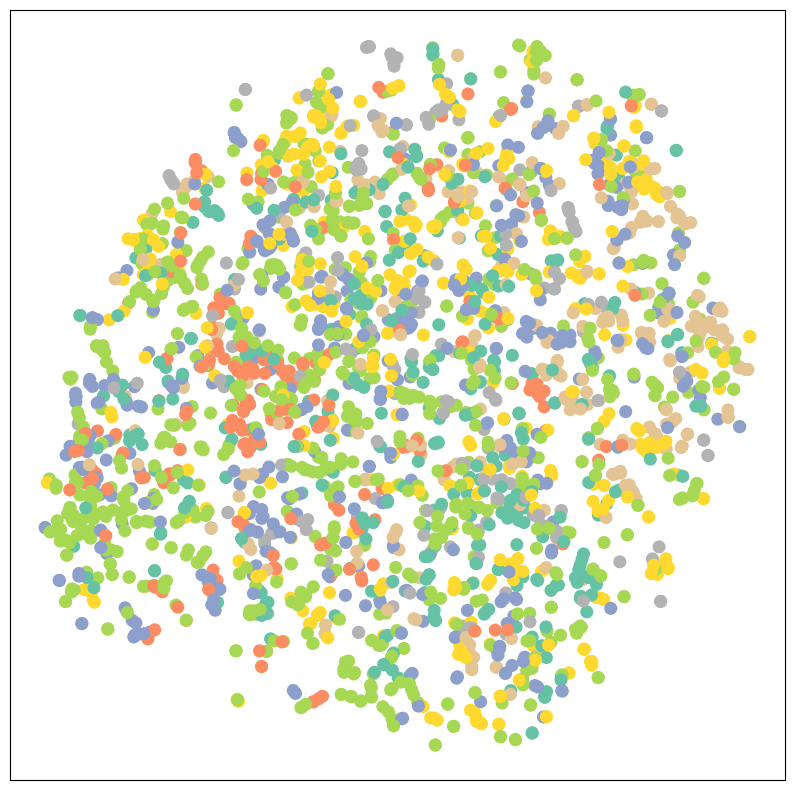

In [14]:
model.eval()

out = model(data.x, data.edge_index)
visualize(out, color=data.y)

## Training GNN

> Model akan dilatih pada 100 epoch menggunakan adam optimizer dan cross-entropy loss.

**Berikut susunan train function nya:**
1. Membersihkan/reset Gradient
2. Melakukan sekali forward pas
3. Hitung loss pakai nodes pada training
4. Hitung gradient, lalu update parameternya

**Berikut susunan test function nya:**
1. Prediksi class dari suatu node
2. Ekstrak label dengan peluang paling tinggi
3. Cek berapa banyak yang diprediksi
4. Membuat _accuracy ratio_ menggunakan jumlah prediksi benar dibagi banyaknya nodes

In [15]:
model = GCN(hidden_channels=16)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
criterion = torch.nn.CrossEntropyLoss()

In [16]:
def train():
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss

def test():
      model.eval()
      out = model(data.x, data.edge_index)
      pred = out.argmax(dim=1)
      test_correct = pred[data.test_mask] == data.y[data.test_mask]
      test_acc = int(test_correct.sum()) / int(data.test_mask.sum())
      return test_acc


for epoch in range(1, 101):
    loss = train()
    print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}')

Epoch: 001, Loss: 1.9465
Epoch: 002, Loss: 1.9419
Epoch: 003, Loss: 1.9363
Epoch: 004, Loss: 1.9290
Epoch: 005, Loss: 1.9199
Epoch: 006, Loss: 1.9140
Epoch: 007, Loss: 1.9079
Epoch: 008, Loss: 1.8992
Epoch: 009, Loss: 1.8876
Epoch: 010, Loss: 1.8764
Epoch: 011, Loss: 1.8656
Epoch: 012, Loss: 1.8626
Epoch: 013, Loss: 1.8460
Epoch: 014, Loss: 1.8329
Epoch: 015, Loss: 1.8225
Epoch: 016, Loss: 1.8167
Epoch: 017, Loss: 1.7995
Epoch: 018, Loss: 1.7878
Epoch: 019, Loss: 1.7716
Epoch: 020, Loss: 1.7568
Epoch: 021, Loss: 1.7563
Epoch: 022, Loss: 1.7342
Epoch: 023, Loss: 1.7092
Epoch: 024, Loss: 1.7015
Epoch: 025, Loss: 1.6671
Epoch: 026, Loss: 1.6757
Epoch: 027, Loss: 1.6609
Epoch: 028, Loss: 1.6355
Epoch: 029, Loss: 1.6339
Epoch: 030, Loss: 1.6102
Epoch: 031, Loss: 1.5964
Epoch: 032, Loss: 1.5721
Epoch: 033, Loss: 1.5570
Epoch: 034, Loss: 1.5445
Epoch: 035, Loss: 1.5093
Epoch: 036, Loss: 1.4889
Epoch: 037, Loss: 1.4776
Epoch: 038, Loss: 1.4704
Epoch: 039, Loss: 1.4263
Epoch: 040, Loss: 1.3972


## Evaluasi Model

In [17]:
test_acc = test()
print(f'Test Accuracy: {test_acc:.4f}')

Test Accuracy: 0.8110


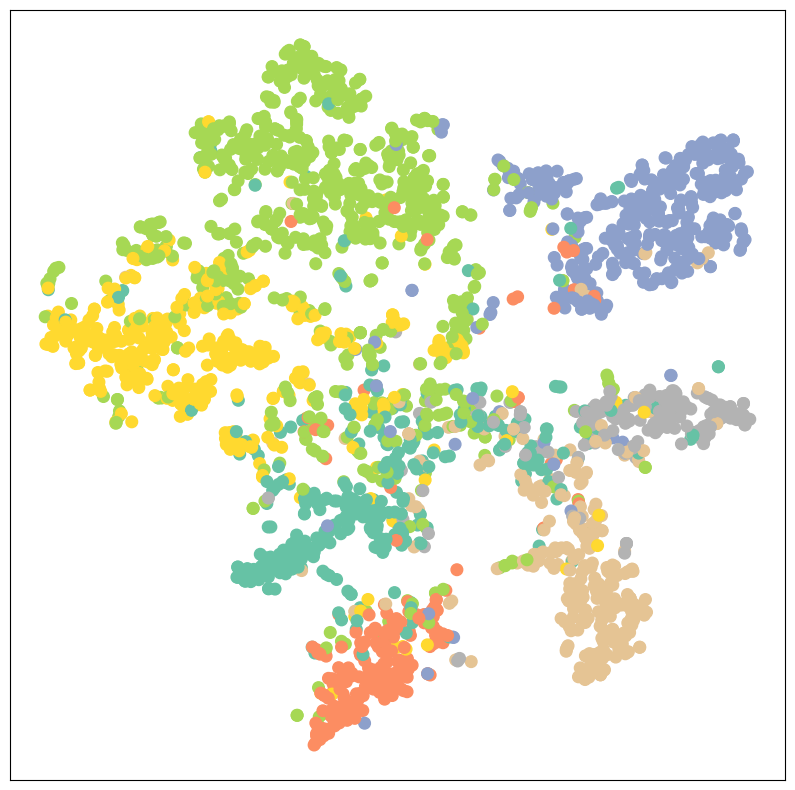

In [18]:
model.eval()
out = model(data.x, data.edge_index)
visualize(out, color=data.y)

> Dari akurasi udah bagus ~81% , ini dibuktikan dari visualisasi gambar diatas yang menghasilkan clust nodes untuk kategori yang sama

## GATConv (Graph Attention Networks) Model

> Di bagian ini kita mengganti _GCN_ dengan _GAT_. Graph Attention Networks menggunakan _masked self-attentional layer_ untuk memperbaiki beberapa kekurangan yang ada di _GCN_

In [19]:
from torch_geometric.nn import GATConv

class GAT(torch.nn.Module):
    def __init__(self, hidden_channels, heads):
        super().__init__()
        torch.manual_seed(1234567)
        self.conv1 = GATConv(dataset.num_features, hidden_channels,heads)
        self.conv2 = GATConv(heads*hidden_channels, dataset.num_classes,heads)

    def forward(self, x, edge_index):
        x = F.dropout(x, p=0.6, training=self.training)
        x = self.conv1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=0.6, training=self.training)
        x = self.conv2(x, edge_index)
        return x

In [20]:
model = GAT(hidden_channels=8, heads=8)
print(model)

optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)
criterion = torch.nn.CrossEntropyLoss()

GAT(
  (conv1): GATConv(1433, 8, heads=8)
  (conv2): GATConv(64, 7, heads=8)
)


In [21]:
def train():
      model.train()
      optimizer.zero_grad()
      out = model(data.x, data.edge_index)
      loss = criterion(out[data.train_mask], data.y[data.train_mask])
      loss.backward()
      optimizer.step()
      return loss

def test(mask):
      model.eval()
      out = model(data.x, data.edge_index)
      pred = out.argmax(dim=1)
      correct = pred[mask] == data.y[mask]
      acc = int(correct.sum()) / int(mask.sum())
      return acc

In [22]:
val_acc_all = []
test_acc_all = []

for epoch in range(1, 101):
    loss = train()
    val_acc = test(data.val_mask)
    test_acc = test(data.test_mask)
    val_acc_all.append(val_acc)
    test_acc_all.append(test_acc)
    print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}, Val: {val_acc:.4f}, Test: {test_acc:.4f}')

Epoch: 001, Loss: 4.0245, Val: 0.1700, Test: 0.2040
Epoch: 002, Loss: 3.9922, Val: 0.2800, Test: 0.3010
Epoch: 003, Loss: 3.9547, Val: 0.3480, Test: 0.3720
Epoch: 004, Loss: 3.9151, Val: 0.3960, Test: 0.4480
Epoch: 005, Loss: 3.8637, Val: 0.4300, Test: 0.4750
Epoch: 006, Loss: 3.8053, Val: 0.4280, Test: 0.4850
Epoch: 007, Loss: 3.7579, Val: 0.4300, Test: 0.4770
Epoch: 008, Loss: 3.6782, Val: 0.4260, Test: 0.4620
Epoch: 009, Loss: 3.5984, Val: 0.4220, Test: 0.4410
Epoch: 010, Loss: 3.5145, Val: 0.4120, Test: 0.4250
Epoch: 011, Loss: 3.4376, Val: 0.3980, Test: 0.4030
Epoch: 012, Loss: 3.3417, Val: 0.3680, Test: 0.3890
Epoch: 013, Loss: 3.2471, Val: 0.3480, Test: 0.3700
Epoch: 014, Loss: 3.1213, Val: 0.3340, Test: 0.3580
Epoch: 015, Loss: 3.0203, Val: 0.3260, Test: 0.3410
Epoch: 016, Loss: 2.9081, Val: 0.3120, Test: 0.3220
Epoch: 017, Loss: 2.7991, Val: 0.2900, Test: 0.3040
Epoch: 018, Loss: 2.6981, Val: 0.2680, Test: 0.2830
Epoch: 019, Loss: 2.5645, Val: 0.2560, Test: 0.2690
Epoch: 020, 

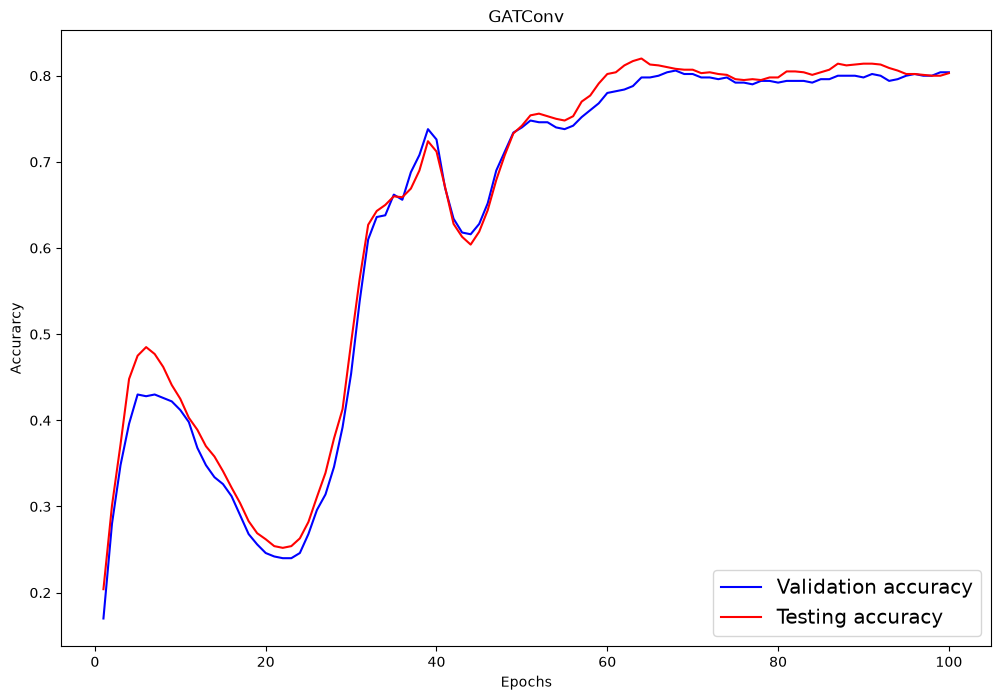

In [23]:
import numpy as np

plt.figure(figsize=(12,8))
plt.plot(np.arange(1, len(val_acc_all) + 1), val_acc_all, label='Validation accuracy', c='blue')
plt.plot(np.arange(1, len(test_acc_all) + 1), test_acc_all, label='Testing accuracy', c='red')
plt.xlabel('Epochs')
plt.ylabel('Accurarcy')
plt.title('GATConv')
plt.legend(loc='lower right', fontsize='x-large')
plt.savefig('gat_loss.png')
plt.show()

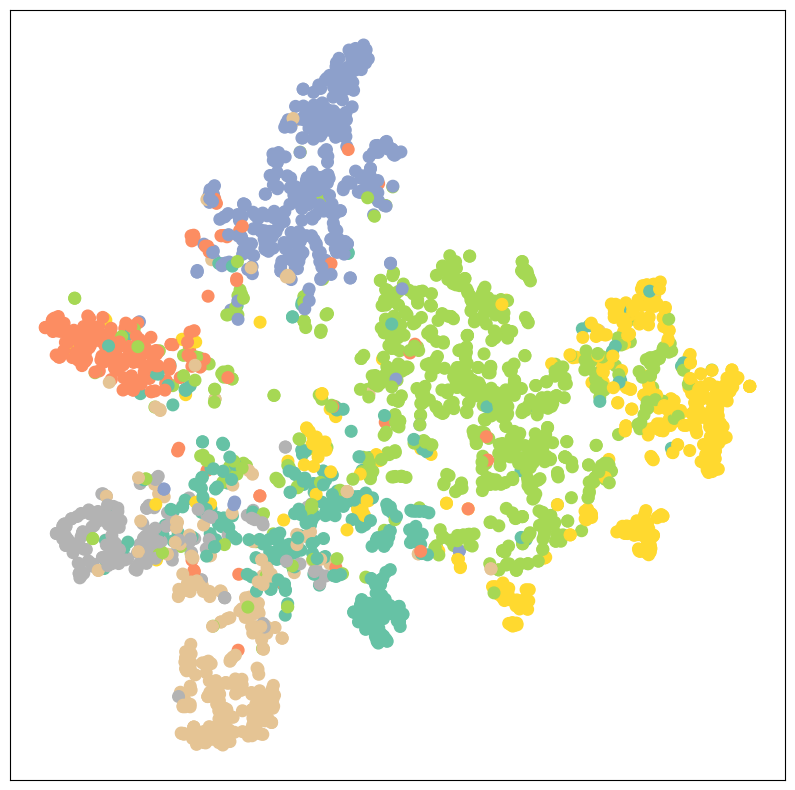

In [24]:
model.eval()

out = model(data.x, data.edge_index)
visualize(out, color=data.y)